Saving PlayTennis.csv to PlayTennis.csv
Dataset:


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


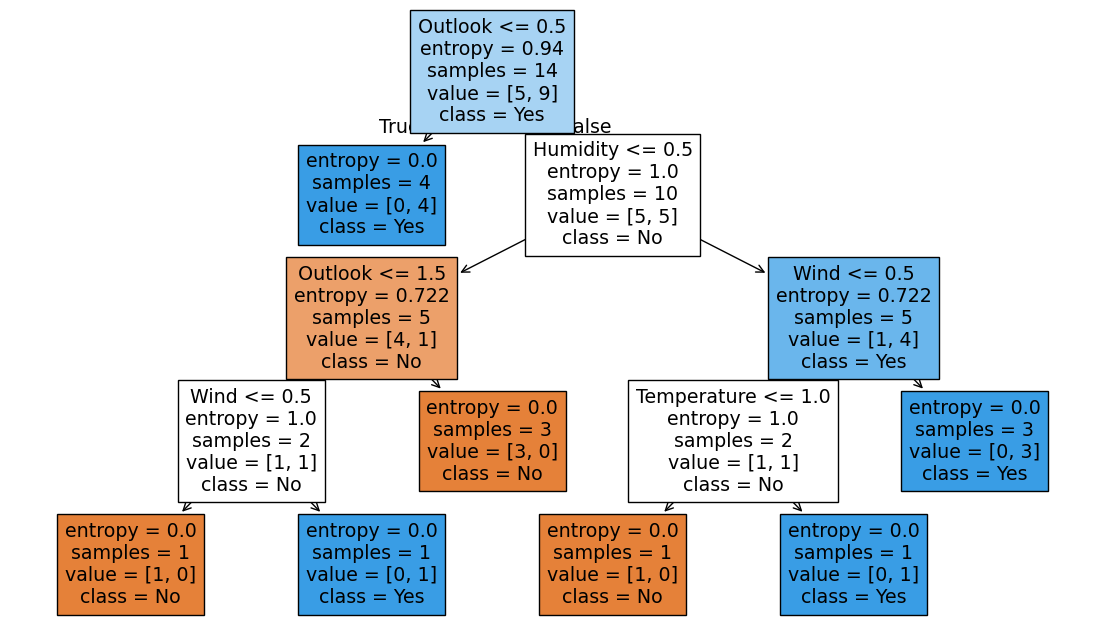

Decision Tree Accuracy: 1.0
Sample: ['Sunny', 'Hot', 'High', 'Weak']
Predicted Class: No


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
# EXPERIMENT 3: ID3 DECISION TREE

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Upload CSV
uploaded = files.upload()

# Read CSV
filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset:")
display(df)

# Separate features and target
X = df.iloc[:, :-1].copy()
y = df.iloc[:, -1].copy()

# Encode categorical columns
encoders = {}

for column in X.columns:
    encoders[column] = LabelEncoder()
    X[column] = encoders[column].fit_transform(X[column])

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# Create ID3 Decision Tree
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X, y)

# Display tree
plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True
)

plt.show()

# Training accuracy
accuracy = model.score(X, y)

print("Decision Tree Accuracy:", accuracy)

# Example prediction
sample = df.iloc[0, :-1].tolist()

sample_encoded = []

for i, column in enumerate(X.columns):
    sample_encoded.append(
        encoders[column].transform([sample[i]])[0]
    )

prediction = model.predict([sample_encoded])

print("Sample:", sample)
print(
    "Predicted Class:",
    target_encoder.inverse_transform(prediction)[0]
)